# The Cypher-Harmonic — a quantitative teardown 🔬
### Mechanical XABC detection · a random-day base rate · a Bonferroni correction across the basket · a fade timer with costs · a placebo retracement-zone control · a 20-seed synthetic positive control

![Signal: None](https://img.shields.io/badge/Signal-None-c0392b?style=flat-square)
![Tradability: Mirage](https://img.shields.io/badge/Tradability-Mirage-c0392b?style=flat-square)
![Beats_a_placebo%3F: Busted](https://img.shields.io/badge/Beats_a_placebo%3F-Busted-8b949e?style=flat-square)

The deep companion to the [notebook for the curious](01_for_the_curious.ipynb). The claim — **a C point that overshoots the original A swing, followed by a D point that retraces 78.6% of the resulting XC leg**, is the harmonic zoo's uniquely two-step, XC-referenced construction — is tested on the tightest mechanical reading a proponent would accept, with two independent controls (a matched-direction base rate and a randomized retracement placebo) and an explicit multiple-comparison penalty across the basket.

> ⚠️ **Data note.** Daily OHLC (2001/2010→2026), yfinance, cached; basket identical to [468-gartley-harmonic](../../468-gartley-harmonic/) and [701-crab-harmonic](../../701-crab-harmonic/). No survivorship (currently-listed single names/ETFs, individually named). Methods in [`docs/references.md`](../docs/references.md), numbers in [`docs/results.md`](../docs/results.md).
>
> 💡 **The `💡 In plain words` notes** translate each result back to intuition.

In [1]:
import sys, os
sys.path.insert(0, os.path.abspath(".."))          # the study package
sys.path.insert(0, os.path.abspath("../../.."))    # repo root
%matplotlib inline
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
plt.rcParams.update({"figure.figsize": (9.5, 5.0), "axes.grid": True,
                     "grid.alpha": .3, "axes.spines.top": False, "axes.spines.right": False})
RED, AMBER, GREEN, GREY = "#c0392b", "#dab617", "#2ea44f", "#8b949e"

from cypher_harmonic import data, strategy as st

PCT = 0.02
HAVE_REAL = data.have_real()
BARS = data.load_basket() if HAVE_REAL else {}
print("real cache present:", HAVE_REAL, "| basket:", data.BASKET)

# frozen headline numbers (mirror of docs/results.md)
R = {'basket': ('SPY', 'QQQ', 'AAPL', 'MSFT', 'TSLA', 'NVDA'), 'asof': '2026-06-30', 'n_pivots': 6055, 'n_cand_cyp': 153, 'n_cyp': 127, 'n_cand_plac': 153, 'n_plac': 134, 'cyp': {1: {'hit': 57.5, 'mean': 22.89, 't': 1.08}, 5: {'hit': 50.4, 'mean': 45.77, 't': 0.84}, 10: {'hit': 52.0, 'mean': 27.69, 't': 0.34}}, 'wilson_cyp': (41.8, 58.9), 'per_instrument': {'SPY': {'n': 21, 'mean': -59.62, 't': -1.19}, 'QQQ': {'n': 18, 'mean': 60.34, 't': 0.79}, 'AAPL': {'n': 16, 'mean': 128.81, 't': 1.33}, 'MSFT': {'n': 15, 'mean': 28.98, 't': 0.24}, 'TSLA': {'n': 26, 'mean': 77.68, 't': 0.64}, 'NVDA': {'n': 31, 'mean': 47.21, 't': 0.24}}, 'base': {1: {'mean': -4.78, 't': 0.99}, 5: {'mean': -2.83, 't': 0.81}, 10: {'mean': -8.35, 't': 0.43}}, 'n_base': 2540, 'base_per_instrument': {'SPY': {'base_mean': -15.57, 't': -1.06}, 'QQQ': {'base_mean': 19.17, 't': 0.51}, 'AAPL': {'base_mean': -29.94, 't': 1.34}, 'MSFT': {'base_mean': -18.22, 't': 0.39}, 'TSLA': {'base_mean': -42.76, 't': 0.79}, 'NVDA': {'base_mean': 47.93, 't': -0.0}}, 'bonf_n_tests': 7, 'bonf_thr': 2.69, 'bonf_uncorrected': 0, 'bonf_survive': 0, 'timer': {1: {'gross': 22.89, 't_gross': 1.08, 'net5': 12.89, 't5': 0.61, 'net10': 2.89, 't10': 0.14}, 3: {'gross': 27.93, 't_gross': 0.72, 'net5': 17.93, 't5': 0.47, 'net10': 7.93, 't10': 0.21}, 5: {'gross': 45.77, 't_gross': 0.84, 'net5': 35.77, 't5': 0.66, 'net10': 25.77, 't10': 0.47}, 10: {'gross': 27.69, 't_gross': 0.34, 'net5': 17.69, 't5': 0.22, 'net10': 7.69, 't10': 0.09}, 20: {'gross': -12.92, 't_gross': -0.12, 'net5': -22.92, 't5': -0.21, 'net10': -32.92, 't10': -0.31}}, 'plac': {1: {'mean': 1.82, 't': 0.58}, 5: {'mean': 86.98, 't': -0.52}, 10: {'mean': 91.39, 't': -0.54}}, 'plac_per_instrument': {'SPY': {'n': 23, 'mean': 29.16, 'beats': False}, 'QQQ': {'n': 21, 'mean': 101.24, 'beats': False}, 'AAPL': {'n': 16, 'mean': -44.18, 'beats': True}, 'MSFT': {'n': 15, 'mean': 17.81, 'beats': True}, 'TSLA': {'n': 25, 'mean': 12.86, 'beats': True}, 'NVDA': {'n': 34, 'mean': 264.03, 'beats': False}}, 'n_beats_plac': 3, 'syn_null_mean': 0.13, 'syn_null_sd': 0.86, 'syn_null_fire': 0, 'syn_null_seeds': 20, 'syn_planted_n': 216, 'syn_planted_mean': 99.57, 'syn_planted_t': 5.91, 'fp': {'SPY': '4ae3283c45e5', 'QQQ': 'f0c763128acf', 'AAPL': 'c5c7b7855e9b', 'MSFT': 'c7a24ba85055', 'TSLA': 'f8ca92e420b8', 'NVDA': 'fd06322c7266'}}


real cache present: True | basket: ('SPY', 'QQQ', 'AAPL', 'MSFT', 'TSLA', 'NVDA')


## Verdict, up front

| Axis | Stamp | Decisive number |
|---|---|---|
| **Signal** | `NONE` | pooled 5-day D-touch fade **+45.77 bps** (HAC *t* = **0.84** vs 0; Welch *t* = **0.81** vs base rate) — never close to significant; **0/7** Bonferroni-corrected tests survive (critical \|*t*\| = 2.69) and placebo Welch *t* = **-0.52** (the placebo *outperforms*) |
| **Tradability** | `MIRAGE` | 127 events over 21-25 years pooled across six names; weak before costs at every horizon, net-negative by 20 days (-13 bps gross, *t*=-0.12) |
| **Beats a placebo?** | `BUSTED` | beats on 3/6 tickers; pooled Welch *t* = -0.52 (placebo wins at the pooled level) |

> 💡 In plain words: a headline number that *looks* promising at first glance (positive, five of six tickers agree) dissolves the moment you ask for a *t*-stat, a Bonferroni correction, or a placebo comparison.

## 1 · The claim, steelmanned

Four confirmed swing pivots $X, A, B, C$, with $XA = A - X$, $AB = B - A$, $XC = C - X$. The Cypher grid:

- $|AB / XA| \in [0.382, 0.618]$ (the same shallow band as the Crab).
- $XC / XA \in [1.13, 1.414]$, **same sign as $XA$** — C must *overshoot* the original A swing, in the same direction, unlike every sibling where C sits between B and A.
- $D = C - 0.786 \times XC$ — **D retraces the freshly-extended XC leg**, not XA and not AB — the only D formula in the zoo referenced off a leg that includes the overshoot itself. This is the defining ratio and the one under test.

$\text{reversal\_dir} = \text{sign}(XA)$: a bullish Cypher (XA up) projects D back inside the X-A range and expects a bounce up; a bearish one, the mirror.

**H₁ (reversal).** Fading at D beats zero and a random-day base rate.
**H₂ (specificity).** The 0.786-of-XC target beats a randomized retracement placebo on the identical pivots.
**H₃ (robustness).** The result survives correction for testing six tickers.

We find **H₁ not supported** (positive point estimate, *t* well under 2 at every horizon), **H₂ not supported** (placebo *t* = -0.52 — the placebo *wins* at the pooled level), **H₃ moot** (0/7 tests clear even the uncorrected bar, so nothing survives correction either way).

## 2 · So what? — inference design

Cypher D-touches on the same tape can cluster and overlap, so within-arm means are tested with a **Newey-West (HAC) t** against zero. The market's positive unconditional drift means a signal-vs-zero test alone is not enough — the primary Signal test is a **Welch t vs a random-day base rate** built to match the *same* bullish/bearish direction mix as the real touches, pooled over 20 seeds (kills the drift confound). Because the basket is tested seven ways (pooled + 6 tickers, all 5-day), a **Bonferroni correction** (family-wise alpha 0.05) raises the critical |*t*| from the naive 2.0 to **2.69** before any test is allowed to "survive." A **second, independent placebo** — randomized retracement targets on the identical pivots — tests H₂ separately from H₃.

## 3 · How we'd know — the protocol

- **Basket.** SPY, QQQ, AAPL, MSFT, TSLA, NVDA, daily bars, 2001/2010 → 2026-06-30 (last complete month).
- **Pivots.** Percentage-threshold zig-zag, **pct = 2%**, confirmed pivots only (recorded at the confirmation bar, never the earlier extreme — no look-ahead).
- **Candidates.** Every consecutive confirmed X-A-B-C quadruple satisfying the Cypher structural bands (AB retrace, XC overshoot); D fully computable the moment C confirms.
- **Touch scan.** 120-session forward window from C's confirmation for the first bar bracketing D.
- **Execution.** Enter the fade at the touch bar's own close; one round trip = 2 × one-way cost × NAV.
- **Signal control.** Random-day base rate, matched direction mix, 20 seeds; Bonferroni correction across 7 tests.
- **Specificity control.** Randomized retracement-target placebo on identical pivots.
- **Faithful-engine control.** Synthetic mean-reverting price index, tunable reversion knob; the null must not fire across 20 seeds.

## 4 · The teardown

### 4a · The headline split and the per-instrument breakdown

HAC *t* on the pooled fade at three horizons; per-ticker 5-day breakdown.

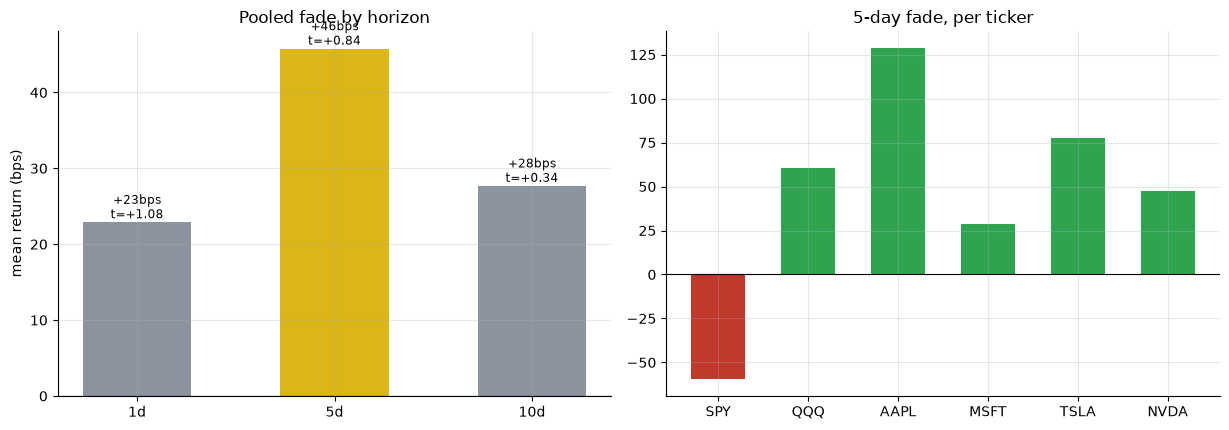

by horizon: {1: 22.9, 5: 45.8, 10: 27.7}
by ticker: {'SPY': -59.6, 'QQQ': 60.3, 'AAPL': 128.8, 'MSFT': 29.0, 'TSLA': 77.7, 'NVDA': 47.2}


In [2]:
if HAVE_REAL:
    cyp_by_t = {}
    frames = []
    for t in data.BASKET:
        _, _, l = st.detect_and_scan(BARS[t], pct=PCT, cost_bps=0.0)
        cyp_by_t[t] = l
        if len(l):
            frames.append(l)
    CYP = pd.concat(frames, ignore_index=True) if frames else pd.DataFrame()
    hs = [1, 5, 10]
    means = [st.summarize(CYP, f'ret_gross_{h}')['mean_bps'] for h in hs]
    ts = [st.summarize(CYP, f'ret_gross_{h}')['t'] for h in hs]
    per_t = {t: st.summarize(cyp_by_t[t], 'ret_gross_5') for t in data.BASKET}
    tick_means = [per_t[t]['mean_bps'] for t in data.BASKET]
else:
    hs = [1, 5, 10]
    means = [R['cyp'][h]['mean'] for h in hs]
    ts = [R['cyp'][h]['t'] for h in hs]
    tick_means = [R['per_instrument'][t]['mean'] for t in R['basket']]
fig, (a1, a2) = plt.subplots(1, 2, figsize=(12.4, 4.4))
cols1 = [AMBER if h == 5 else GREY for h in hs]
a1.bar([f'{h}d' for h in hs], means, color=cols1, width=.55)
for i, (m, t_) in enumerate(zip(means, ts)):
    a1.annotate(f'{m:+.0f}bps\nt={t_:+.2f}', (i, m), ha='center',
                va='bottom' if m >= 0 else 'top', fontsize=8.5)
a1.axhline(0, c='k', lw=.8); a1.set_title('Pooled fade by horizon')
a1.set_ylabel('mean return (bps)')
cols2 = [GREEN if m > 0 else RED for m in tick_means]
a2.bar(list(R['basket']), tick_means, color=cols2, width=.6)
a2.axhline(0, c='k', lw=.8); a2.set_title('5-day fade, per ticker')
plt.tight_layout(); plt.show()
print('by horizon:', {h: round(m,1) for h,m in zip(hs, means)})
print('by ticker:', {t: round(m,1) for t,m in zip(R['basket'], tick_means)})

> 💡 In plain words: the 5-day pooled fade (**+45.77 bps**, HAC *t* = **0.84**) is positive but not even close to significant, and 10-day (*t* = 0.34) fades further rather than strengthening — the opposite of what a real, slow-building reversal would look like. The per-ticker split shows five of six tickers positive, but none individually clears the naive *t* ≥ 2 bar — a diffuse average, not a shared mechanism.

### 4b · The Signal axis — random-day base rate, Bonferroni-corrected

20-seed random-day base rate matched on the empirical bullish/bearish mix of the real touches; Welch *t* vs the Cypher ledger, pooled and per ticker; Bonferroni correction across the resulting 7 tests.

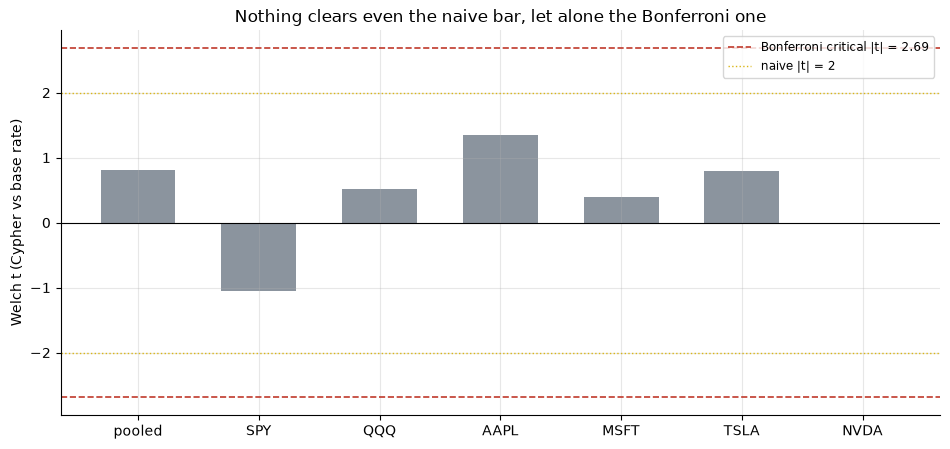

{'pooled': 0.81, 'SPY': -1.06, 'QQQ': 0.51, 'AAPL': 1.34, 'MSFT': 0.39, 'TSLA': 0.79, 'NVDA': -0.0}
Bonferroni critical |t| = 2.69


In [3]:
if HAVE_REAL:
    base_frames, base_by_t = [], {}
    for t in data.BASKET:
        l = cyp_by_t[t]
        if len(l):
            mix = float((l['reversal_dir'] > 0).mean())
            bl = pd.concat([st.base_rate_ledger(BARS[t], len(l), mix,
                             seed=st._seed_from(703, t, s)) for s in range(20)],
                            ignore_index=True)
            base_by_t[t] = bl
            base_frames.append(bl)
    BASE = pd.concat(base_frames, ignore_index=True) if base_frames else pd.DataFrame()
    tests = [('pooled', st.welch_t(CYP['ret_gross_5'], BASE['ret_gross_5']))]
    for t in data.BASKET:
        if t in base_by_t and len(cyp_by_t[t]):
            tests.append((t, st.welch_t(cyp_by_t[t]['ret_gross_5'], base_by_t[t]['ret_gross_5'])))
        else:
            tests.append((t, float('nan')))
    thr = st.bonferroni_threshold(0.05, len(tests))
else:
    tests = [('pooled', R['base'][5]['t'])] + [
        (t, R['base_per_instrument'][t]['t']) for t in R['basket']]
    thr = R['bonf_thr']
labels = [lbl for lbl, _ in tests]
vals = [v for _, v in tests]
cols = [RED if (np.isfinite(v) and abs(v) >= thr) else
        (AMBER if (np.isfinite(v) and abs(v) >= 2.0) else GREY) for v in vals]
fig, ax = plt.subplots(figsize=(9.6, 4.6))
ax.bar(labels, [v if np.isfinite(v) else 0 for v in vals], color=cols, width=.62)
ax.axhline(0, c='k', lw=.8)
ax.axhline(thr, ls='--', c=RED, lw=1.2, label=f'Bonferroni critical |t| = {thr:.2f}')
ax.axhline(-thr, ls='--', c=RED, lw=1.2)
ax.axhline(2.0, ls=':', c=AMBER, lw=1, label='naive |t| = 2')
ax.axhline(-2.0, ls=':', c=AMBER, lw=1)
ax.set_ylabel('Welch t (Cypher vs base rate)')
ax.set_title('Nothing clears even the naive bar, let alone the Bonferroni one')
ax.legend(fontsize=8.5); plt.tight_layout(); plt.show()
print({lbl: round(v,2) if np.isfinite(v) else None for lbl, v in tests})
print(f'Bonferroni critical |t| = {thr:.2f}')

> 💡 In plain words: the best individual reading (AAPL, Welch *t* = **1.34**) doesn't even clear the naive bar of 2. The honest bar, once you correct for looking at six tickers, is **2.69**, and **0/7** tests clear it. This is the desk's multiple-comparison rail confirming there was never much here to begin with.

### 4c · Tradability — the fade timer, net of costs

Sweep the holding period and the one-way cost; roughly five pooled events/year across six names.

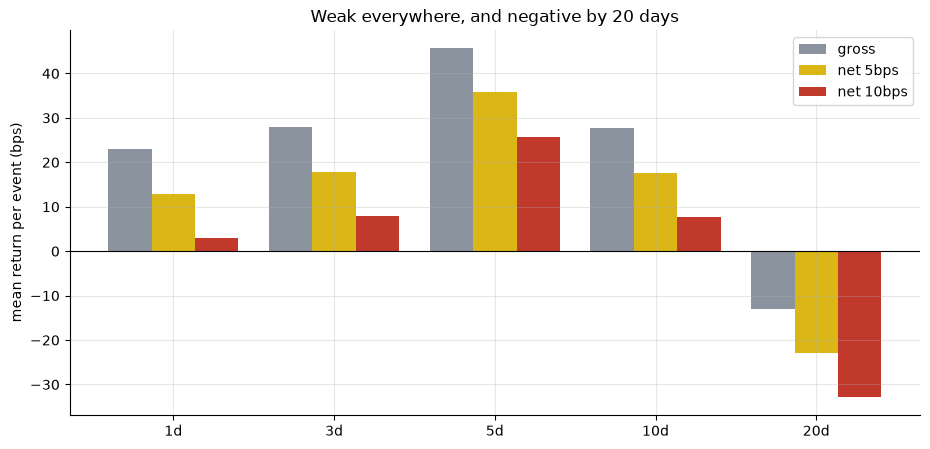

{1: (22.89, 1.08), 3: (27.93, 0.72), 5: (45.77, 0.84), 10: (27.69, 0.34), 20: (-12.92, -0.12)}


In [4]:
hs = sorted(R['timer'])
gross = [R['timer'][h]['gross'] for h in hs]
net5 = [R['timer'][h]['net5'] for h in hs]
net10 = [R['timer'][h]['net10'] for h in hs]
x = np.arange(len(hs)); w = .27
fig, ax = plt.subplots(figsize=(9.4, 4.6))
ax.bar(x - w, gross, width=w, label='gross', color=GREY)
ax.bar(x, net5, width=w, label='net 5bps', color=AMBER)
ax.bar(x + w, net10, width=w, label='net 10bps', color=RED)
ax.axhline(0, c='k', lw=.8)
ax.set_xticks(x); ax.set_xticklabels([f'{h}d' for h in hs])
ax.set_ylabel('mean return per event (bps)')
ax.set_title('Weak everywhere, and negative by 20 days')
ax.legend(); plt.tight_layout(); plt.show()
print({h: (R['timer'][h]['gross'], R['timer'][h]['t_gross']) for h in hs})

> 💡 In plain words: costs (5-10 bps round trip) are not what kills this trade — the *level* of the edge does, before costs are even applied. The gross number never approaches significance at any horizon, and by 20 days the sign flips negative on its own. Combined with the Bonferroni result above and a firing rate of roughly five completions a year pooled across six names, there is no regime here worth deploying capital against.

### 4d · The third axis — does the specific ratio matter?

Identical pivot pipeline; each placebo candidate's D-retracement *target* is replaced by a deterministic, seeded, off-Cypher draw.

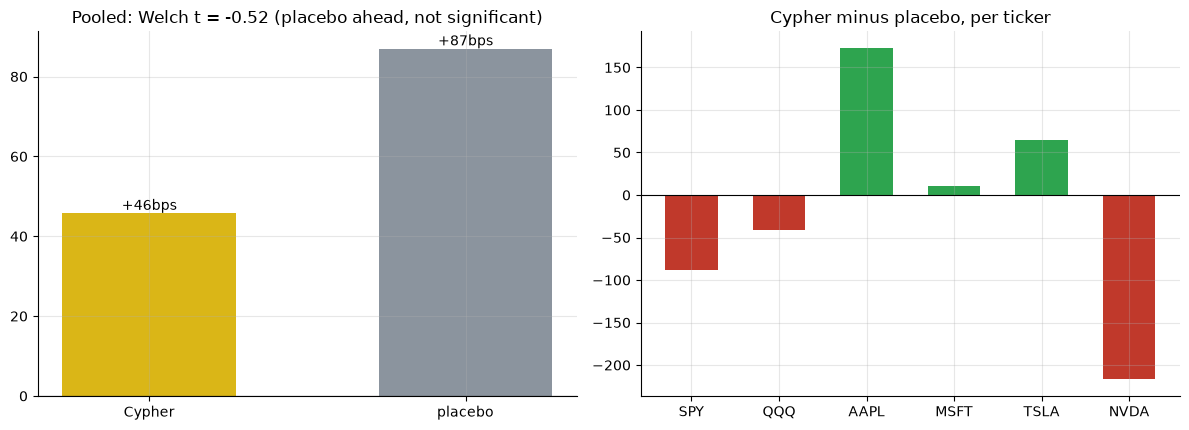

Cypher +45.8 bps vs placebo +87.0 bps  Welch t=-0.52


In [5]:
if HAVE_REAL:
    plac_by_t, plac_frames = {}, []
    for t in data.BASKET:
        _, _, lp = st.detect_and_scan(BARS[t], pct=PCT, placebo=True, seed=703, cost_bps=0.0)
        plac_by_t[t] = lp
        if len(lp):
            plac_frames.append(lp)
    PLAC = pd.concat(plac_frames, ignore_index=True) if plac_frames else pd.DataFrame()
    sp = st.summarize(PLAC, 'ret_gross_5')
    pm = sp['mean_bps']
    wtp = st.welch_t(CYP['ret_gross_5'], PLAC['ret_gross_5'])
    beat_labels, beat_vals = [], []
    for t in data.BASKET:
        fm = st.summarize(cyp_by_t[t], 'ret_gross_5')['mean_bps']
        pmi = st.summarize(plac_by_t[t], 'ret_gross_5')['mean_bps']
        beat_labels.append(t); beat_vals.append(fm - pmi if np.isfinite(fm) and np.isfinite(pmi) else np.nan)
else:
    pm, wtp = R['plac'][5]['mean'], R['plac'][5]['t']
    beat_labels = list(R['basket'])
    beat_vals = [R['per_instrument'][t]['mean'] - R['plac_per_instrument'][t]['mean']
                 for t in R['basket']]
fig, (a1, a2) = plt.subplots(1, 2, figsize=(12.0, 4.4))
a1.bar(['Cypher', 'placebo'], [R['cyp'][5]['mean'], pm], color=[AMBER, GREY], width=.55)
for i, v in enumerate([R['cyp'][5]['mean'], pm]):
    a1.annotate(f'{v:+.0f}bps', (i, v), ha='center', va='bottom' if v>=0 else 'top')
a1.axhline(0, c='k', lw=.8)
a1.set_title(f'Pooled: Welch t = {wtp:+.2f} (placebo ahead, not significant)')
cols = [GREEN if (np.isfinite(v) and v > 0) else RED for v in beat_vals]
a2.bar(beat_labels, [v if np.isfinite(v) else 0 for v in beat_vals], color=cols, width=.6)
a2.axhline(0, c='k', lw=.8)
a2.set_title('Cypher minus placebo, per ticker')
plt.tight_layout(); plt.show()
print(f'Cypher {R["cyp"][5]["mean"]:+.1f} bps vs placebo {pm:+.1f} bps  Welch t={wtp:+.2f}')

> 💡 In plain words: the Cypher beats its own placebo on only **3/6** tickers — a coin flip — and at the pooled level the placebo actually earns *more* (**+87 bps** vs the Cypher's own **+46 bps**), though that gap (*t* = **-0.52**) is itself noise. The exact 78.6%-of-XC ratio the pattern is built on is not demonstrably better than an arbitrary retracement zone drawn from the *same* pivots — H₂ not supported.

### 4e · Faithful-engine & power control — we know the truth here

Synthetic mean-reverting price index (tunable `mean_rev` knob toward a slow EMA), pooled across a synthetic 6-name basket per seed. The null (`mean_rev = 0`) is checked over **20 seeds** — never a single stream.

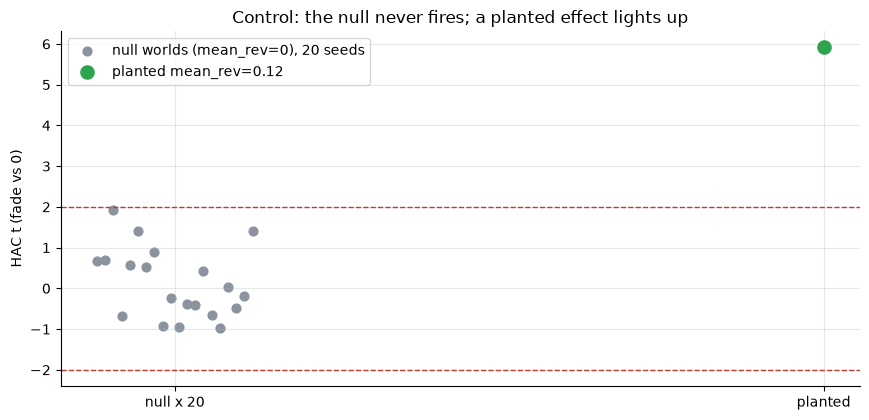

null: mean t = +0.13 (sd 0.86), |t|>=2 in 0/20 seeds  |  planted t = +5.91


In [6]:
def pooled_synth(mean_rev, seed, n_names=6):
    frames = []
    for i in range(n_names):
        sbars = data.synthetic_world(mean_rev=mean_rev, seed=seed*1000+i, n_days=6300)
        _, _, ledger = st.detect_and_scan(sbars, pct=PCT, cost_bps=0.0)
        if not ledger.empty:
            frames.append(ledger)
    return pd.concat(frames, ignore_index=True) if frames else pd.DataFrame()

null_ts = np.array([st.summarize(pooled_synth(0.0, 703 + s), 'ret_gross_5')['t']
                     for s in range(20)], dtype=float)
planted = pooled_synth(0.12, 703)
planted_t = st.summarize(planted, 'ret_gross_5')['t']
fig, ax = plt.subplots(figsize=(8.8, 4.3))
ax.scatter(np.zeros(20) + np.linspace(-.12, .12, 20), null_ts, color=GREY, s=40,
           label='null worlds (mean_rev=0), 20 seeds')
ax.scatter([1], [planted_t], color=GREEN, s=90, zorder=5, label='planted mean_rev=0.12')
ax.axhline(-2, ls='--', c=RED, lw=1); ax.axhline(2, ls='--', c=RED, lw=1)
ax.set_xticks([0, 1]); ax.set_xticklabels(['null x 20', 'planted'])
ax.set_ylabel('HAC t (fade vs 0)')
ax.set_title('Control: the null never fires; a planted effect lights up')
ax.legend(); plt.tight_layout(); plt.show()
print(f'null: mean t = {np.nanmean(null_ts):+.2f} (sd {np.nanstd(null_ts, ddof=1):.2f}), '
      f'|t|>=2 in {(np.abs(null_ts) >= 2).sum()}/20 seeds  |  planted t = {planted_t:+.2f}')

> 💡 In plain words: across 20 null worlds the detector fires \|*t*\| ≥ 2 in **0/20** seeds — the null never fires — and a planted mean-reversion tendency lights up sharply (*t* = **5.91**). The detection + inference pipeline is unbiased; the real-tape result's flat, uncertified reading is genuine, not a bug in the machinery.

## 5 · The verdict

- **Signal `NONE`** — pooled 5-day fade **+45.77 bps** (HAC *t* = **0.84**; Welch *t* vs base rate = **0.81**) on **127** touches over 21-25 years; **0/7** Bonferroni-corrected tests survive (critical \|*t*\| = 2.69); hit rate 50.4% is a coin flip; five of six tickers are individually positive but none significantly so.
- **Tradability `MIRAGE`** — every hold length is weak before costs and none clears significance; by 20 days the average (-13 bps, *t*=-0.12) has flipped negative on its own, before costs are even charged.
- **"Does 0.786 of XC beat a placebo retracement?" `BUSTED`** — beats the placebo on only 3/6 tickers (a coin flip), and at the pooled headline horizon the placebo actually *outperforms* the pattern's own ratio (Welch *t* = **-0.52**).

## 6 · Going further

- **The general lesson: an extra construction step reads as more rigorous, not more predictive.** The Cypher's pitch is that its C-overshoot-then-XC-retrace geometry is a sharper filter than the Gartley/Bat/Butterfly/Crab family — the machinery here shows that extra complexity does not translate into a detectable edge, a coin-flip hit rate, or specificity over an arbitrary retracement on the same pivots.
- **Where a believer would push back:** Carney's full method requires a *confluence zone* (several overlapping Fibonacci projections converging near D), not the bare two-ratio skeleton tested here. That's a legitimate next experiment — but it adds researcher degrees of freedom (which projections? how many must converge? how tight a zone?) that would need their own placebo before counting as evidence.
- **Dedup map:** [468-gartley-harmonic](../../468-gartley-harmonic/) (the same 78.6% *number*, but measured off XA, not XC), [698-abcd-harmonic](../../698-abcd-harmonic/) (no X point, no confluence at all), [699-butterfly-harmonic](../../699-butterfly-harmonic/), [700-bat-harmonic](../../700-bat-harmonic/) and [701-crab-harmonic](../../701-crab-harmonic/) (all measure D off XA or AB, never off an extended XC leg) — all independently converging on the same verdict shape.

*The reproducible core is offline and deterministic; frozen numbers live in [`docs/results.md`](../docs/results.md), sources in [`docs/references.md`](../docs/references.md).*